In [2]:
# Numpy für bessere Berechnungen
import numpy as np
from numpy import exp, sqrt, log, pi
from uncertainties import unumpy as unp

# Weiteres für bessere Rechnungen
import pylab as py

from decimal import Decimal, ROUND_CEILING, ROUND_HALF_UP, getcontext # Besonders für sig. Runden
import math

# Berechnungen und Plotting
from scipy import odr
import scipy.optimize
import scipy.constants as c
from scipy.optimize import curve_fit
from scipy.stats import chi2
from scipy.stats import poisson
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.signal import argrelextrema, argrelmin, argrelmax
from scipy.special import factorial

%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as transforms

# Zum Auslesen von Dateien und ähnlichem
import os
import os.path
from pathlib import Path

import pandas as pd # Auch wichtig für den Latex Export
from pytexit import py2tex
import csv
import re
from typing import List


# Besseres Funktionen handling
import sympy as sp
from sympy import separatevars

# Display und Output
from IPython.display import display, Math, Latex, HTML

# Grafiken in EU-Größen ausgeben
def figsize_cm(width_cm, height_cm):
    return (2*width_cm / 2.54, 2*height_cm / 2.54)
def comma_to_float(valstr):
    return float(valstr.replace(',','.'))

g=9.80984 
Delta_g=0.00002


In [3]:
currentversuch = "223"
base = Path.cwd()                   
Messwerte_path = Path(base.parent.parent.parent/"Messwerte"/currentversuch)      # initializing paths
Ausgabe_path = Path(base/"Diagramme")
print(Messwerte_path)
print(Ausgabe_path)



c:\Users\samue\OneDrive\Dokumente\PAP\PAP2.1\Messwerte\223
c:\Users\samue\OneDrive\Dokumente\PAP\PAP2.1\Auswertungen\Code\222\Diagramme


Runden signifikanter Stellen

In [4]:
def round_to_sigs(val, errVal,einheiten):
    """
    Funktion zur Rundung eines Fehlers und die Anpassung des Messwertes daran. Diese Funktion wurde etwas umständlicher 
    geschrieben, da python mit Floats und Runden schnell in Probleme rennt. Daher musste hier mit dezimal gearbeitet werden.
    Zudem sollten besonders kleine und große Messwerte in der Dezimalschreibweise geschrieben werden, damit diese auch 
    für Protokolle geiegnet sind.

    Parameter
    ----------
    **val** : float
        Messwert

    **errVal** : float
        Ungenauigkeit des Messwertes

    Return
    ------
    **value_rounded** : str
        Gerundeter Messwert

    **error_rounded** : str
        Gerundete Ungenauigkeit des Messwertes

    **res** : str
        "Messwert \\pm Fehler"
    """

    # Daten zu Dezimal wechseln, da Floats probleme machen
    val = Decimal(str(val))
    errVal = Decimal(str(errVal))

    exp = int(math.floor(math.log10(float(errVal))))            # Die erste signifikante Stellenposition wird anhand des errVal bestimmt

    if round(float(errVal / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1

    scale = Decimal(10) ** exp                                  

    val_round = (val / scale).quantize(Decimal('1'), rounding=ROUND_HALF_UP) * scale            # mit scale wird das Komma so verschoben, dass alle signifikanten Stellen vor dem Komma stehen, und dann alle Nachkommastellen weggerundet werden
    err_round = (errVal / scale).quantize(Decimal('1'), rounding=ROUND_CEILING) * scale

    qty = f"\\qty{{{val_round}({err_round})}}{{{einheiten}}}"
    num = f"\\num{{{val_round}({err_round})}}"
    return float(val_round), float(err_round), num, qty

v_round = np.vectorize(round_to_sigs, otypes=[float, float, object, object], excluded=['einheiten'])

    # wissenschaftliche Notation erstmal vernachlässigen (da häufig Einheiten gewollt sind, die 10^/e Prefixe beinhalten)

Gausssche Fehlerfortpflanzung

In [5]:
def gff(function, errPronePar,latex=True):
    """
    Kann die Fehlerformel einer gegebenen Gleichung bestimmen.

    Parameters
    ----------
    **func** : sympy function
        Funktion dessen Fehler bestimmt werden soll.

    **errPronePar** : Array
        Liste (Array) aller fehlerbehafteten Größen der Gleichung con sp.Symbols
        Diese Werte werden als x_sym, y_sym, z_sym etc. bezeichnet und sind ungleich den Werten für x, y, z.
        Für die Werte wird daher die Bezeichnung x_val, y_val, z_val etc. genutzt und für deren Fehler err_x, err_y, err_z etc.

    Return
    ----------
    **absolut_err** : sympy function
        Gibt die Fehlergleichung des absoluten Fehlers wieder. 

    **relativ_err** : sympy function
        Gibt die Fehlergleichung des relativen Fehlers wieder. 
        
    **errProneParamters** : array
        Liste aller Fehlerbehafteten Größen
    """ 

    error = 0
    errProneParamaters = []

    function = sp.sympify(function)
    variables = errPronePar.split(",")
    variables = sp.symbols(variables)

    for variable in variables:
        Delta = sp.Symbol(f"Delta_{variable}")
        partial = sp.diff(function, variable)                   # Die Funktion wird nach der fehlerbehafteten Variable abgeleitet
        term=sp.UnevaluatedExpr(partial*Delta)**2
        error = error + ((term))                                # Fehler werden quadratisch aufsummiert
        errProneParamaters.append((variable,Delta))
    
    absolute_err=sp.simplify(sp.sqrt(error),rational = True)             
    relative_err=sp.simplify(sp.sqrt(error/function**2),rational = True)
    
    if latex:
        #Prints out the Latex Code for the Functions
        print("Funktion:")
        display(Math(sp.latex(function,long_frac_ratio=2))) 
        print(sp.latex(function))
        print("Absoluter Fehler:")
        display(Math(sp.latex(absolute_err,long_frac_ratio=2)))
        print(sp.latex(absolute_err))
        print("Relativer Fehler:")
        display(Math(sp.latex(relative_err,long_frac_ratio=2)))
        print(sp.latex(relative_err))
    return function,absolute_err, relative_err, errProneParamaters


Sigma-Abweichungen

In [6]:
def sigma_abweichung(p1, err_p1,p2,err_p2):
    """
    Funktion zum berechnen der Sigma-Abweichugn von zwei Messwerten, oder einem Messwert und einem Literaturwert.
    """
    if err_p1 == 0 and err_p2 == 0:
        raise ValueError("Für die Sigma-Abweichung muss mindestens ein Wert fehlerbehaftet sein!")
    else:
        abweichung=Decimal(str(abs(p1 - p2)/(np.sqrt(err_p1 ** 2+err_p2 ** 2))))
    
    exp = int(math.floor(math.log10(float(abweichung))))
    if round(float(abweichung / (Decimal(10) ** exp))) < 3:         # wenn 1,2,3 erste signifikante Stelle, dann kommt eine zweite Nachkommastellenposition hinzu
        exp -= 1
    scale = Decimal(10) ** exp   
    abweichung_round = (abweichung / scale).quantize(Decimal('1'), rounding=ROUND_CEILING) * scale
    res = f"\\num{{{abweichung_round}}}"

    return float(abweichung_round),res



In [7]:
c_W=4180
rho_W=998

I_H=5.75 
Delta_I_H=0.03*I_H+0.1
U_H=5.31
Delta_U_H=0.01*U_H+0.03
P_K=U_H*I_H
Delta_P_K=P_K*np.sqrt(Delta_I_H**2/I_H**2 + Delta_U_H**2/U_H**2)
P_K,Delta_P_K,_,quant=round_to_sigs(P_K,Delta_P_K,r'\watt')

f=np.mean([329.5,306.8,300.2])/60
Delta_f=np.sqrt((np.std([329.5,306.8,300.2])/60)**2+(3/60)**2)
f,Delta_f,_,_=round_to_sigs(f,Delta_f,r'\per\s')
print(f,Delta_f)
dotV=np.mean([286.7,287.3,285.3,289.1,258.9])*1e-6/60
Delta_dotV=np.std([286.7,287.3,285.3,289.1,258.9])*1e-6/60
dotV,Delta_dotV,_,_=round_to_sigs(dotV,Delta_dotV,r'\m\cubed\per\s')
T_1=21.3
T_2=18.1
Delta_T_1=0.002*T_1
Delta_T_2=0.002*T_2
T=T_1-T_2
Delta_T= np.sqrt(Delta_T_1**2 + Delta_T_2**2)
T,Delta_T,_,_=round_to_sigs(T,Delta_T,r'\kelvin')

Q_1=c_W*rho_W*T*dotV/f
Delta_Q_1= Q_1*np.sqrt(Delta_T**2/T**2 + Delta_dotV**2/dotV**2 + Delta_f**2/f**2)#
Q_1,Delta_Q_1,_,latexq1=round_to_sigs(Q_1,Delta_Q_1,r'\J')
print(latexq1)
Q_2=P_K/f
Delta_Q_2=Q_2*np.sqrt(Delta_P_K**2/P_K**2 + Delta_f**2/f**2)
Q_2,Delta_Q_2,_,latexq2=round_to_sigs(Q_2,Delta_Q_2,r'\J')
print(latexq2)

I_M=3.2
Delta_I_M=0.03*I_M+0.1
U_M=28.1
Delta_U_M=0.01*U_M+0.03

W_M=I_M*U_M/f
Delta_W_M=W_M*np.sqrt(Delta_I_M**2/I_M**2 + Delta_U_M**2/U_M**2 + Delta_f**2/f**2)
W_M,Delta_W_M,_,latexwm=round_to_sigs(W_M,Delta_W_M,r'\J')
print(latexwm)

Q_V1=W_M-Q_1+Q_2
Delta_Q_V1=np.sqrt(Delta_Q_1**2 + Delta_Q_2**2 + Delta_W_M**2)
Q_V1,Delta_Q_V1,_,latexQ_V=round_to_sigs(Q_V1,Delta_Q_V1,r'J')
print(latexQ_V)

nK=Q_2/W_M
Delta_nK=nK*np.sqrt(Delta_Q_2**2/Q_2**2 + Delta_W_M**2/W_M**2)
nK,Delta_nK,_,latexnk=round_to_sigs(nK,Delta_nK,r'')
print(latexnk)


5.2 0.22
\qty{12.0(0.8)}{\J}
\qty{5.9(0.4)}{\J}
\qty{17.3(1.4)}{\J}
\qty{11.2(1.7)}{J}
\qty{0.34(0.04)}{}


In [8]:
t_0=96
Delta_t_0=10
V_W=1*1e-6
Delta_V_W=0.3*1e-6
lambda_W=335*1e3
P_K=V_W*lambda_W*rho_W/t_0
Delta_P_K=P_K*np.sqrt(Delta_V_W**2/V_W**2 + Delta_t_0**2/t_0**2)
P_K,Delta_P_K,_,latexpk=round_to_sigs(P_K,Delta_P_K,r'\watt')
print(latexpk)

nK2=P_K/f/W_M
print(nK2)
Delta_nK2=nK2*np.sqrt(Delta_P_K**2/P_K**2 +Delta_f**2/f**2 + Delta_W_M**2/W_M**2)
nK2,Delta_nK2,_,latexnk2=round_to_sigs(nK2,Delta_nK2,r'\percent')
print(latexnk2)

\qty{3.5(1.2)}{\watt}
0.038906180524677626
\qty{0.039(0.014)}{\percent}


In [9]:

# #Größenvergleich in latex
# def size_comp_str(name1,name2,val1,val2):
#     if val1<val2:
#         return name1+"<"+name2
#     elif val1>val2:
#         return name1+">"+name2
#     else:
#         return name1+"="+name2
   
#Erstellung von Vergleichstabellen in Latex
import textwrap 
def compare_table(nam1,nam2,einheiten,val1,err1,val2,err2):
    VAL1=round_to_sigs(val1,err1,r'')[2]
    VAL2=round_to_sigs(val2,err2,r'')[2]
    abs=np.abs(val1-val2)
    abs_delta=np.sqrt(err1**2+err2**2)
    if abs_delta!=0:
        SIGMA=sigma_abweichung(val1,val2,err1,err2)[1]
    else:
        SIGMA=0.0
    ABS=round_to_sigs(abs,abs_delta,r'')[2]
    rel=abs/np.abs(val1)*100
    rel_delta=rel*np.sqrt((abs_delta/abs)**2+(err1/val1)**2) if abs != 0 else 0
    REL=round_to_sigs(rel,rel_delta,r'')[2]
    output = textwrap.dedent(f"""
        \\begin{{table}}[htb]
        \\centering
        \\caption{{}}
        \\begin{{tabularx}}{{0.8\\textwidth}}{{ZZZZZ}}
            \\toprule
                {nam1}[\\unit{{{einheiten}}}]&{nam2}[\\unit{{{einheiten}}}]&\\text{{abs.Abw.}}[\\unit{{{einheiten}}}]&\\text{{proz.Abw.}}[\\unit{{\\percent}}]&S[\\sigma]\\\\\\midrule
                {VAL1}&{VAL2}&{ABS}&{REL}&{SIGMA}\\\\
            \\bottomrule
        \\end{{tabularx}}
        \\label{{table:Vergleich_{nam1}}} 
        \\end{{table}}
    """)
    print(output)


In [10]:
compare_table(r'P_K',r'P_K',r'\watt',30.6,1.6,3.5,1.2)


\begin{table}[htb]
\centering
\caption{}
\begin{tabularx}{0.8\textwidth}{ZZZZZ}
    \toprule
        P_K[\unit{\watt}]&P_K[\unit{\watt}]&\text{abs.Abw.}[\unit{\watt}]&\text{proz.Abw.}[\unit{\percent}]&S[\sigma]\\\midrule
        \num{30.6(1.6)}&\num{3.5(1.2)}&\num{27.1(2.0)}&\num{89(9)}&\num{8}\\
    \bottomrule
\end{tabularx}
\label{table:Vergleich_P_K} 
\end{table}



In [11]:
f=np.mean([253.9,253.4,250.2,280.6,294.0])/60
Delta_f=np.sqrt((np.std([253.9,253.4,250.2,280.6,294.0])/60)**2+(3/60)**2)
f,Delta_f,latexf,_=round_to_sigs(f,Delta_f,r'\per\s')
print(latexf)

U_H=12.74
Delta_U_H=0.01*U_H+0.03
I_H=15
Delta_I_H=0.03*I_H+0.1
P_K=U_H*I_H
Delta_P_K=P_K*np.sqrt(Delta_I_H**2/I_H**2 + Delta_U_H**2/U_H**2)
P_el,Delta_P_el,latexpel,quant=round_to_sigs(P_K,Delta_P_K,r'\watt')
print(latexpel)
Q_2=P_K/f
Delta_Q_2=Q_2*np.sqrt(Delta_P_K**2/P_K**2 + Delta_f**2/f**2)
Q_el,Delta_Q_el,latexqel,_=round_to_sigs(Q_2,Delta_Q_2,r'\J')
print(latexqel)

dotV=np.mean([284.9,287.1,286.8,286.3])*1e-6/60
Delta_dotV=np.std([284.9,287.1,286.8,286.3])*1e-6/60
dotV,Delta_dotV,_,_=round_to_sigs(dotV,Delta_dotV,r'\m\cubed\per\s')
T_1=23.1
T_2=18.4
Delta_T_1=0.002*T_1
Delta_T_2=0.002*T_2
T=T_1-T_2
Delta_T= np.sqrt(Delta_T_1**2 + Delta_T_2**2)
T,Delta_T,_,_=round_to_sigs(T,Delta_T,r'\kelvin')
Q_1=c_W*rho_W*T*dotV
Delta_Q_1= Q_1*np.sqrt(Delta_T**2/T**2 + Delta_dotV**2/dotV**2)
Q_1,Delta_Q_1,latexpab,_=round_to_sigs(Q_1,Delta_Q_1,r'\J')
print(latexpab)
Q_ab=c_W*rho_W*T*dotV/f
Delta_Q_ab= Q_ab*np.sqrt(Delta_T**2/T**2 + Delta_dotV**2/dotV**2 + Delta_f**2/f**2)#
Q_ab,Delta_Q_ab,latexqab,_=round_to_sigs(Q_ab,Delta_Q_ab,r'\J')
print(latexqab)

A=np.mean([30612.0,30160.0,30100.0])*100*1e-6
Delta_A=np.std([30612.0,30160.0,30100.0])*100*1e-6
WpV,Delta_WpV,latexWpv,_=round_to_sigs(A,Delta_A,r'\J')
print("wpV"+latexWpv)
PpV,Delta_PpV,latexppv,_=round_to_sigs(WpV*f,np.sqrt((Delta_WpV/WpV)**2+(Delta_f/f)**2),r'\J')
print("ppv"+latexppv)
 
eta=WpV/Q_el
Delta_eta=eta*np.sqrt((Delta_WpV/WpV)**2+(Delta_Q_el/Q_el)**2)
eta,Delta_eta,latexeta,_=round_to_sigs(eta,Delta_eta,r'')
print(latexeta)

Q_VERLUSTE=Q_el-Q_ab 
Delta_Q_VERLUSTE= np.sqrt(Delta_Q_ab**2 + Delta_Q_el**2)
Q_VERLUSTE,Delta_Q_VERLUSTE,_,latexqver=round_to_sigs(Q_VERLUSTE,Delta_Q_VERLUSTE,r'\J')
print(latexqver)  

\num{4.4(0.3)}
\num{191(8)}
\num{43(4)}
\num{93.5(1.3)}
\num{21.3(1.5)}
wpV\num{3.029(0.023)}
ppv\num{13.33(0.07)}
\num{0.070(0.007)}
\qty{22(5)}{\J}


In [12]:
l=0.25
F=np.array([0.8,0.6,0.4,0.2])
Delta_F=0.05
F,Delta_F,latexF,_=v_round(F,Delta_F,r'\N')
fwerte=np.array([[217.6,219.9,220.2],[225.1,230.4,235.3],[249.0,247.8,246.3],[263.2,262.9,260.9]])
f=np.mean(fwerte,axis=1)/60
Delta_f=np.sqrt((np.std(fwerte,axis=1)/60)**2+(3/60)**2)
f,Delta_f,latexf,_=v_round(f,Delta_f,r'\per\s')

Awerte=np.array([[36804.0,36200.0,36410.0],[34680.0,35100.0,35070],[33590.0,33180.0,33540.0],[32490.0,31700.0,32250.0]])
A=np.mean(Awerte,axis=1)*100*1e-6
Delta_A=np.std(Awerte,axis=1)*100*1e-6
WpV,Delta_WpV,latexwpv,_=v_round(A,Delta_A,r'\J')

W_D=2*np.pi*l*F
Delta_W_D=2*np.pi*l*np.sqrt(Delta_F**2)
W_D,Delta_W_D,latexwd,_=v_round(W_D,Delta_W_D,r'\J')

Q_el=P_el/f
Delta_Q_el=Q_el*np.sqrt(Delta_P_el**2/P_el**2 + Delta_f**2/f**2)
Q_el,Delta_Q_el,latexqel,_=v_round(Q_el,Delta_Q_el,r'\J')

n_th=WpV/Q_el*100
Delta_n_th=n_th*np.sqrt((Delta_WpV/WpV)**2+(Delta_Q_el/Q_el)**2)
n_th,Delta_n_th,latexnth,_=v_round(n_th,Delta_n_th,r'')

n_eff=W_D/Q_el*100
Delta_n_eff=n_eff*np.sqrt((Delta_W_D/W_D)**2+(Delta_Q_el/Q_el)**2)
n_eff,Delta_n_eff,latexneff,_=v_round(n_eff,Delta_n_eff,r'')

for i in range(4):
    print(f"{latexF[i]}&{latexf[i]}&{latexwpv[i]}&{latexqel[i]}&{latexwd[i]}&{latexnth[i]}&{latexneff[i]}\\\\")

\num{0.80(0.05)}&\num{3.65(0.06)}&\num{3.65(0.03)}&\num{52.3(2.4)}&\num{1.26(0.08)}&\num{7.0(0.4)}&\num{2.41(0.19)}\\
\num{0.60(0.05)}&\num{3.84(0.09)}&\num{3.495(0.020)}&\num{49.7(2.4)}&\num{0.94(0.08)}&\num{7.0(0.4)}&\num{1.89(0.19)}\\
\num{0.40(0.05)}&\num{4.13(0.06)}&\num{3.344(0.019)}&\num{46.2(2.1)}&\num{0.63(0.08)}&\num{7.2(0.4)}&\num{1.36(0.19)}\\
\num{0.20(0.05)}&\num{4.37(0.06)}&\num{3.21(0.04)}&\num{43.7(2.0)}&\num{0.31(0.08)}&\num{7.3(0.4)}&\num{0.71(0.19)}\\


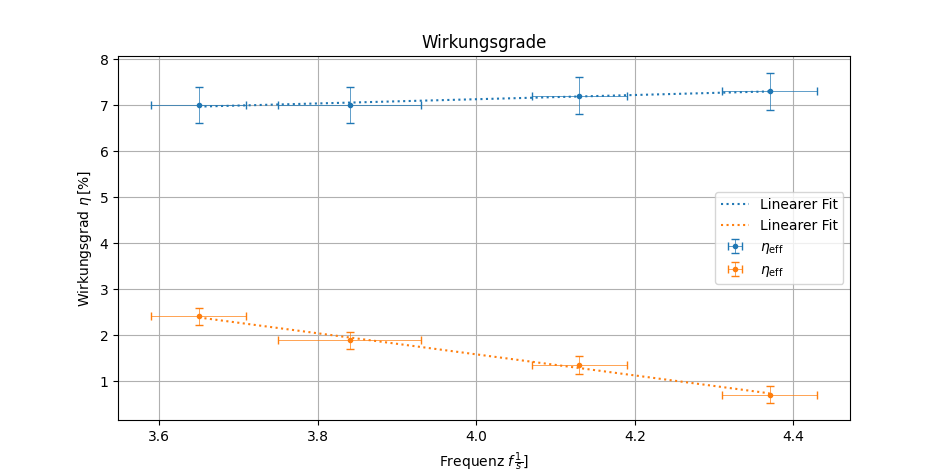

In [13]:
plt.close('all')

fig, ax = plt.subplots(figsize=figsize_cm(12,6))
ax.set_title('Wirkungsgrade')
ax.set_xlabel(r'Frequenz $f\,\frac{1}{s}$]')
ax.set_ylabel(r'Wirkungsgrad $\eta\,[\%]$')
# ax.set_ylim((3e1,1*1e2))
# ax.set_xlim(())
def lin(x,a,b):
    return a*x + b

ax.errorbar(x=f,xerr=Delta_f,y=n_th,yerr=Delta_n_th,fmt=".",capsize=3,elinewidth=0.5,label=r'$\eta_\text{eff}$')
ax.errorbar(x=f,xerr=Delta_f,y=n_eff,yerr=Delta_n_eff,fmt=".",capsize=3,elinewidth=0.5,label=r'$\eta_\text{eff}$')
popt, pcov = curve_fit(lin, f, n_th,  sigma = Delta_n_th,absolute_sigma=True) 
popt1, pcov1 = curve_fit(lin, f, n_eff,  sigma = Delta_n_eff,absolute_sigma=True) 
ax.plot(f, lin(f,*popt), color=f"C{0}",linestyle='dotted',label='Linearer Fit')
ax.plot(f, lin(f,*popt1), color=f"C{1}",linestyle='dotted',label='Linearer Fit')


ax.grid()
ax.legend()
plt.show()
plt.savefig(Ausgabe_path/"Nr.neffnth.png",format="png")
#

In [14]:
gff("2*pi*l*F","F")

Funktion:


<IPython.core.display.Math object>

2 \pi F l
Absoluter Fehler:


<IPython.core.display.Math object>

2 \pi \sqrt{\Delta_{F}^{2} l^{2}}
Relativer Fehler:


<IPython.core.display.Math object>

\sqrt{\frac{\Delta_{F}^{2}}{F^{2}}}


(2*pi*F*l, 2*pi*sqrt(Delta_F**2*l**2), sqrt(Delta_F**2/F**2), [(F, Delta_F)])

In [15]:
h_1=np.array([7.85,6.25,4.50,4.00])
h_3=np.array([2.20,1.65,1.20,1.10])
Delta_h_1=Delta_h_3=round_to_sigs(h_1[0],np.sqrt(2)*0.5*1e-1,r"m")[1]
kappa_CD=(h_1/(h_1 - h_3))
Delta_kappa_CD=np.sqrt((Delta_h_1**2*h_3**2 + Delta_h_3**2*h_1**2)/(h_1 - h_3)**4)
kappa_CD,Delta_kappa_CD,latexkappa,_ = v_round(kappa_CD, Delta_kappa_CD,r"\m")
print(kappa_CD)
print(Delta_kappa_CD)
bar_kappa_CD=np.sum(kappa_CD/Delta_kappa_CD**2)/np.sum(1/Delta_kappa_CD**2)
bar_Delta_kappa_CD=np.sqrt(1/np.sum(1/Delta_kappa_CD**2))
for i in range(len(h_1)):
    print(f"\\num{{{h_1[i]}({Delta_h_1})}}&\\num{{{h_3[i]}({Delta_h_1})}}&{latexkappa[i]}\\\\")

print(round_to_sigs(bar_kappa_CD,bar_Delta_kappa_CD,r"")[2])

[1.389 1.359 1.36  1.38 ]
[0.021 0.025 0.04  0.04 ]
\num{7.85(0.08)}&\num{2.2(0.08)}&\num{1.389(0.021)}\\
\num{6.25(0.08)}&\num{1.65(0.08)}&\num{1.359(0.025)}\\
\num{4.5(0.08)}&\num{1.2(0.08)}&\num{1.36(0.04)}\\
\num{4.0(0.08)}&\num{1.1(0.08)}&\num{1.38(0.04)}\\
\num{1.375(0.014)}
